In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing

data=fetch_california_housing()

df=pd.DataFrame(data.data,columns=data.feature_names)
df['Price']=data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.shape

(20640, 9)

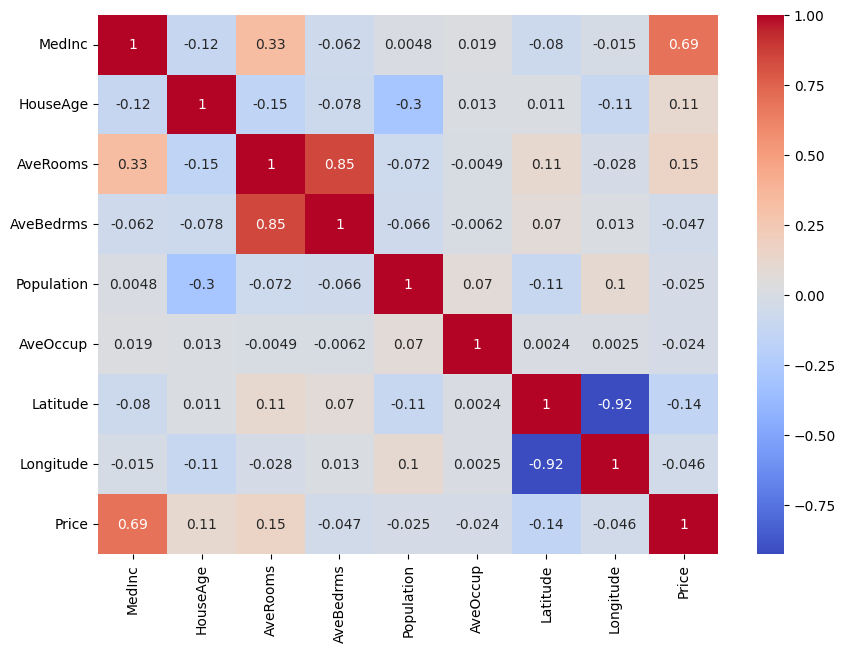

In [7]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

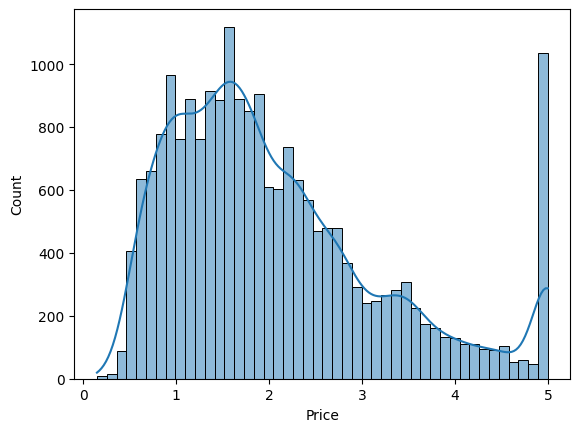

In [8]:
sns.histplot(df['Price'],kde=True)
plt.show()

In [9]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [11]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)

IQR=Q3-Q1
df=df[~((df<(Q1-1.5*IQR)) | (df>(Q3+1.5*IQR))).any(axis=1)]

In [12]:
X=df.drop('Price',axis=1).values
y=df['Price'].values

mean=np.mean(X,axis=0)
std=np.std(X,axis=0)
X=(X-mean)/std

In [13]:
X=np.c_[np.ones(X.shape[0]),X]

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
theta=np.zeros(X_train.shape[1])

In [16]:
def compute_cost(X,y,theta):
    m=len(y)
    predictions=X.dot(theta)
    cost=(1/(2*m))*np.sum((predictions-y)**2)
    return cost

In [17]:
def gradient_descent(X,y,theta,lr,iterations):
    m=len(y)
    cost_history=[]

    for i in range(iterations):
        predictions=X.dot(theta)
        gradient=(1/m)*X.T.dot(predictions-y)

        theta=theta-lr*gradient
        cost=compute_cost(X,y,theta)
        cost_history.append(cost)
    return theta,cost_history

In [18]:
learning_rates=[0.1,0.01,0.001]

histories={}

for lr in learning_rates:
    theta=np.zeros(X_train.shape[1])
    theta,cost_history=gradient_descent(X_train,y_train,theta,lr,500)
    histories[lr]=cost_history

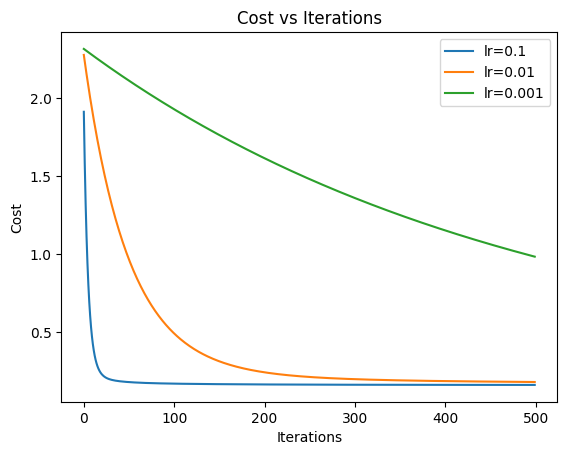

In [19]:
for lr in histories:
    plt.plot(histories[lr],label=f"lr={lr}")

plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

In [20]:
y_pred=X_test.dot(theta)

In [21]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
R2=r2_score(y_test,y_pred)

print(MAE,MSE,RMSE,R2)

1.1564196183039186 1.904911880587853 1.3801854515201402 -1.1792316947245194


In [22]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train[:,1:],y_train)
sk_pred=model.predict(X_test[:,1:])
print("SKlearn R2:",r2_score(y_test,sk_pred))

SKlearn R2: 0.6378964374821561


In [23]:
def SGD(X,y,theta,lr,epochs):
    m=len(y)
    for epoch in range(epochs):
        for i in range(m):
            rand=np.random.randint(0,m)
            xi=X[rand:rand+1]
            yi=y[rand:rand+1]

            prediction=xi.dot(theta)
            gradient=xi.T.dot(prediction-yi)
            
            theta=theta-lr*gradient

    return theta

In [24]:
theta_sgd=np.zeros(X_train.shape[1])
theta_sgd=SGD(X_train,y_train,theta_sgd,lr=0.01,epochs=10)

y_pred_sgd=X_test.dot(theta_sgd)
print("SGD R2:",r2_score(y_test,y_pred_sgd))

SGD R2: 0.6182519702823893
